In [ ]:
# necessary imports
import matplotlib.pyplot as plt
import re
import numpy as np 
import re
from glob import glob

In [11]:
# Helper function to extract numeric arrays
def extract_arrays(block_text):
    """Extracts all bracketed numeric arrays from a text block."""
    arrays = re.findall(r"\[([^\]]+)\]", block_text)
    parsed = [np.fromstring(a.replace(",", " "), sep=" ") for a in arrays]
    return np.array(parsed)


# Combine arrays across files
def safe_stack(arr_list):
    return np.vstack(arr_list) if arr_list else np.empty((0, 4))


# Compute summary stats
def summarize(metric, name):
    if metric.size == 0:
        print(f"\n{name}: No data found.")
        return
    mean_per_class = np.mean(metric, axis=0)
    std_per_class = np.std(metric, axis=0)
    macro_mean = np.mean(mean_per_class)
    macro_std = np.std(mean_per_class)

    print(f"\n{name} Results:")
    print(f"Mean per Class: {np.round(mean_per_class, 4)}")
    print(f"Std per Class:  {np.round(std_per_class, 4)}")
    print(f"Macro Mean: {macro_mean:.4f}, Macro Std: {macro_std:.4f}")


## population non individual 

In [ ]:
# Loop over saved model reports for each modality
files_noindi_pop= ["Reports/noindi_pop_0", "Reports/noindi_pop_1", "Reports/noindi_pop_2",   "Reports/noindi_pop_3"]

# Containers for all metrics
f1_all, recall_all, precision_all, pr_auc_all = [], [], [], []

# General regex patterns to locate metric blocks
patterns = {
    "F1 Measure": r"F1 Measure per Class:\s*((?:\[[^\]]+\],?\s*)+)",
    "Recall": r"Recall per Class:\s*((?:\[[^\]]+\],?\s*)+)",
    "Precision": r"Precision per Class:\s*((?:\[[^\]]+\],?\s*)+)",
    "PR AUC": r"PR AUC per Class:\s*((?:\[[^\]]+\],?\s*)+)"
}


# Loop through all .txt files in the current folder
for file in files_noindi_pop:
    with open(file, "r") as f:
        text = f.read()

    for metric_name, pattern in patterns.items():
        match = re.search(pattern, text)
        if not match:
            continue
        arrays = extract_arrays(match.group(1))
        if arrays.size == 0:
            continue

        if metric_name == "F1 Measure":
            f1_all.append(arrays)
        elif metric_name == "Recall":
            recall_all.append(arrays)
        elif metric_name == "Precision":
            precision_all.append(arrays)
        elif metric_name == "PR AUC":
            pr_auc_all.append(arrays)



f1_all = safe_stack(f1_all)
recall_all = safe_stack(recall_all)
precision_all = safe_stack(precision_all)
pr_auc_all = safe_stack(pr_auc_all)

# Summarize all metrics
summarize(recall_all, "Recall")
summarize(precision_all, "Precision")
summarize(f1_all, "F1 Measure")
summarize(pr_auc_all, "PR AUC")


Recall Results:
Mean per Class: [1.     0.7927 0.5916 0.777 ]
Std per Class:  [0.     0.0687 0.0916 0.0519]
Macro Mean: 0.7903, Macro Std: 0.1446

Precision Results:
Mean per Class: [0.9997 0.7093 0.5272 0.8519]
Std per Class:  [0.0007 0.0749 0.0501 0.0397]
Macro Mean: 0.7720, Macro Std: 0.1747

F1 Measure Results:
Mean per Class: [0.9998 0.7469 0.5558 0.8114]
Std per Class:  [0.0003 0.0632 0.0633 0.0338]
Macro Mean: 0.7785, Macro Std: 0.1586

PR AUC Results:
Mean per Class: [1.     0.8156 0.5451 0.9028]
Std per Class:  [0.     0.0749 0.0824 0.0326]
Macro Mean: 0.8159, Macro Std: 0.1694


## Age-based Individualized with 5 epochs 

In [ ]:
# Containers for all values
f1_all, recall_all, precision_all, prauc_all = [], [], [], []

# Loop over saved model reports for each age group
files_indi_agegroup = ["Reports/5Ep_indi_agegroup_0.txt", 
                    "Reports/5Ep_indi_agegroup_1.txt",
         "Reports/5Ep_indi_agegroup_2.txt", 
         "Reports/5Ep_indi_agegroup_3.txt"]


# Containers for all metrics
f1_all, recall_all, precision_all, pr_auc_all = [], [], [], []

# General regex patterns to locate metric blocks
patterns = {
    "F1 Measure": r"F1 Measure per Class:\s*((?:\[[^\]]+\],?\s*)+)",
    "Recall": r"Recall per Class:\s*((?:\[[^\]]+\],?\s*)+)",
    "Precision": r"Precision per Class:\s*((?:\[[^\]]+\],?\s*)+)",
    "PR AUC": r"PR AUC per Class:\s*((?:\[[^\]]+\],?\s*)+)"
}



# Loop through all .txt files in the current folder
for file in files_indi_agegroup:
    with open(file, "r") as f:
        text = f.read()

    for metric_name, pattern in patterns.items():
        match = re.search(pattern, text)
        if not match:
            continue
        arrays = extract_arrays(match.group(1))
        if arrays.size == 0:
            continue

        if metric_name == "F1 Measure":
            f1_all.append(arrays)
        elif metric_name == "Recall":
            recall_all.append(arrays)
        elif metric_name == "Precision":
            precision_all.append(arrays)
        elif metric_name == "PR AUC":
            pr_auc_all.append(arrays)


f1_all = safe_stack(f1_all)
recall_all = safe_stack(recall_all)
precision_all = safe_stack(precision_all)
pr_auc_all = safe_stack(pr_auc_all)


# Summarize all metrics
summarize(recall_all, "Recall")
summarize(precision_all, "Precision")
summarize(f1_all, "F1 Measure")
summarize(pr_auc_all, "PR AUC")



Recall Results:
Mean per Class: [0.9969 0.8027 0.6058 0.7341]
Std per Class:  [0.01   0.0554 0.0835 0.0718]
Macro Mean: 0.7849, Macro Std: 0.1413

Precision Results:
Mean per Class: [0.9983 0.6787 0.5004 0.8598]
Std per Class:  [0.0024 0.0822 0.0683 0.031 ]
Macro Mean: 0.7593, Macro Std: 0.1876

F1 Measure Results:
Mean per Class: [0.9975 0.7328 0.5461 0.7901]
Std per Class:  [0.005  0.0605 0.0675 0.0471]
Macro Mean: 0.7667, Macro Std: 0.1610

PR AUC Results:
Mean per Class: [1.     0.7921 0.517  0.8973]
Std per Class:  [0.0001 0.0756 0.094  0.0326]
Macro Mean: 0.8016, Macro Std: 0.1800


## Population based individualized, fine tuned for 10 epochs 

In [ ]:
# Loop over saved model reports for each age group 
files_indi_agegroup = ["Reports/10_Ep_indi_agegroup_0.txt", "Reports/10_Ep_indi_agegroup_1.txt", "Reports/10_Ep_indi_agegroup_2.txt", 
         "/Reports/10_Ep_indi_agegroup_3.txt"]


# Containers for all metrics
f1_all, recall_all, precision_all, pr_auc_all = [], [], [], []

# General regex patterns to locate metric blocks
patterns = {
    "F1 Measure": r"F1 Measure per Class:\s*((?:\[[^\]]+\],?\s*)+)",
    "Recall": r"Recall per Class:\s*((?:\[[^\]]+\],?\s*)+)",
    "Precision": r"Precision per Class:\s*((?:\[[^\]]+\],?\s*)+)",
    "PR AUC": r"PR AUC per Class:\s*((?:\[[^\]]+\],?\s*)+)"
}


# Loop through all .txt files in the current folder
for file in files_indi_agegroup:
    with open(file, "r") as f:
        text = f.read()

    for metric_name, pattern in patterns.items():
        match = re.search(pattern, text)
        if not match:
            continue
        arrays = extract_arrays(match.group(1))
        if arrays.size == 0:
            continue

        if metric_name == "F1 Measure":
            f1_all.append(arrays)
        elif metric_name == "Recall":
            recall_all.append(arrays)
        elif metric_name == "Precision":
            precision_all.append(arrays)
        elif metric_name == "PR AUC":
            pr_auc_all.append(arrays)

f1_all = safe_stack(f1_all)
recall_all = safe_stack(recall_all)
precision_all = safe_stack(precision_all)
pr_auc_all = safe_stack(pr_auc_all)

# Summarize all metrics
summarize(f1_all, "F1 Measure")
summarize(recall_all, "Recall")
summarize(precision_all, "Precision")
summarize(pr_auc_all, "PR AUC")



F1 Measure Results:
Mean per Class: [0.9962 0.7224 0.5362 0.7849]
Std per Class:  [0.0063 0.0591 0.0648 0.0423]
Macro Mean: 0.7599, Macro Std: 0.1643

Recall Results:
Mean per Class: [0.9954 0.7964 0.5968 0.7272]
Std per Class:  [0.0114 0.0603 0.0858 0.0609]
Macro Mean: 0.7789, Macro Std: 0.1440

Precision Results:
Mean per Class: [0.9971 0.6648 0.4893 0.856 ]
Std per Class:  [0.0062 0.0747 0.0591 0.0354]
Macro Mean: 0.7518, Macro Std: 0.1920

PR AUC Results:
Mean per Class: [1.     0.7826 0.5015 0.8937]
Std per Class:  [0.0001 0.0783 0.0876 0.0332]
Macro Mean: 0.7944, Macro Std: 0.1858


## Population based individualized, fine tuned for 25

In [ ]:
# Loop over saved model reports for each age group
files_indi_agegroup = ["Reports/25_Ep_indi_agegroup_0.txt",  "Reports/25_Ep_indi_agegroup_1.txt", "Reports/25_Ep_indi_agegroup_2.txt", 
                       "/Reports/25_Ep_indi_agegroup_3.txt"]


# Containers for all metrics
f1_all, recall_all, precision_all, pr_auc_all = [], [], [], []

# General regex patterns to locate metric blocks
patterns = {
    "F1 Measure": r"F1 Measure per Class:\s*((?:\[[^\]]+\],?\s*)+)",
    "Recall": r"Recall per Class:\s*((?:\[[^\]]+\],?\s*)+)",
    "Precision": r"Precision per Class:\s*((?:\[[^\]]+\],?\s*)+)",
    "PR AUC": r"PR AUC per Class:\s*((?:\[[^\]]+\],?\s*)+)"
}


# Loop through all .txt files in the current folder
for file in files_indi_agegroup:
    with open(file, "r") as f:
        text = f.read()

    for metric_name, pattern in patterns.items():
        match = re.search(pattern, text)
        if not match:
            continue
        arrays = extract_arrays(match.group(1))
        if arrays.size == 0:
            continue

        if metric_name == "F1 Measure":
            f1_all.append(arrays)
        elif metric_name == "Recall":
            recall_all.append(arrays)
        elif metric_name == "Precision":
            precision_all.append(arrays)
        elif metric_name == "PR AUC":
            pr_auc_all.append(arrays)

f1_all = safe_stack(f1_all)
recall_all = safe_stack(recall_all)
precision_all = safe_stack(precision_all)
pr_auc_all = safe_stack(pr_auc_all)


# Summarize all metrics
summarize(f1_all, "F1 Measure")
summarize(recall_all, "Recall")
summarize(precision_all, "Precision")
summarize(pr_auc_all, "PR AUC")



F1 Measure Results:
Mean per Class: [0.9859 0.7073 0.527  0.7801]
Std per Class:  [0.0657 0.0742 0.0623 0.0372]
Macro Mean: 0.7501, Macro Std: 0.1644

Recall Results:
Mean per Class: [0.9807 0.7767 0.5907 0.7237]
Std per Class:  [0.0939 0.0682 0.0914 0.0558]
Macro Mean: 0.7680, Macro Std: 0.1403

Precision Results:
Mean per Class: [0.9976 0.655  0.4797 0.8492]
Std per Class:  [0.0027 0.0928 0.0574 0.038 ]
Macro Mean: 0.7454, Macro Std: 0.1957

PR AUC Results:
Mean per Class: [0.9997 0.7522 0.4862 0.8861]
Std per Class:  [0.0016 0.1034 0.0851 0.036 ]
Macro Mean: 0.7811, Macro Std: 0.1914


## Population based individualized, fine tuned for 5 epochs

In [ ]:
# Containers for all values
f1_all, recall_all, precision_all, prauc_all = [], [], [], []

# Loop over saved model reports for each age group
files_indi_pop = ["Reports/5Ep_indi_pop_0", "Reports/5Ep_indi_pop_1", "Reports/5Ep_indi_pop_2",  "Reports/5Ep_indi_pop_3"]


# Containers for all metrics
f1_all, recall_all, precision_all, pr_auc_all = [], [], [], []

# General regex patterns to locate metric blocks
patterns = {
    "F1 Measure": r"F1 Measure per Class:\s*((?:\[[^\]]+\],?\s*)+)",
    "Recall": r"Recall per Class:\s*((?:\[[^\]]+\],?\s*)+)",
    "Precision": r"Precision per Class:\s*((?:\[[^\]]+\],?\s*)+)",
    "PR AUC": r"PR AUC per Class:\s*((?:\[[^\]]+\],?\s*)+)"
}


# Loop through all .txt files in the current folder
for file in files_indi_pop:
    with open(file, "r") as f:
        text = f.read()

    for metric_name, pattern in patterns.items():
        match = re.search(pattern, text)
        if not match:
            continue
        arrays = extract_arrays(match.group(1))
        if arrays.size == 0:
            continue

        if metric_name == "F1 Measure":
            f1_all.append(arrays)
        elif metric_name == "Recall":
            recall_all.append(arrays)
        elif metric_name == "Precision":
            precision_all.append(arrays)
        elif metric_name == "PR AUC":
            pr_auc_all.append(arrays)


f1_all = safe_stack(f1_all)
recall_all = safe_stack(recall_all)
precision_all = safe_stack(precision_all)
pr_auc_all = safe_stack(pr_auc_all)


# Summarize all metrics
summarize(recall_all, "Recall")
summarize(precision_all, "Precision")
summarize(f1_all, "F1 Measure")
summarize(pr_auc_all, "PR AUC")


Recall Results:
Mean per Class: [0.9953 0.8048 0.6172 0.7394]
Std per Class:  [0.019  0.0575 0.0865 0.065 ]
Macro Mean: 0.7892, Macro Std: 0.1367

Precision Results:
Mean per Class: [0.9975 0.6804 0.5082 0.8646]
Std per Class:  [0.0067 0.0861 0.0621 0.0333]
Macro Mean: 0.7627, Macro Std: 0.1851

F1 Measure Results:
Mean per Class: [0.9963 0.735  0.556  0.7957]
Std per Class:  [0.0103 0.0662 0.0686 0.0454]
Macro Mean: 0.7707, Macro Std: 0.1572

PR AUC Results:
Mean per Class: [1.     0.7995 0.5292 0.9006]
Std per Class:  [0.0002 0.0919 0.0937 0.0326]
Macro Mean: 0.8073, Macro Std: 0.1755


## Age based non individual 

In [ ]:
# Containers for all values
f1_all, recall_all, precision_all, prauc_all = [], [], [], []

# Loop over saved model reports for each age group
filest_noindi_agegroup = ["Reports/noindi_agegroup_0.txt", "Reports/noindi_agegroup_1.txt","Reports/noindi_agegroup_2.txt",
                    "Reports/noindi_agegroup_3.txt"]


# Containers for all metrics
f1_all, recall_all, precision_all, pr_auc_all = [], [], [], []

# General regex patterns to locate metric blocks
patterns = {
    "F1 Measure": r"F1 Measure per Class:\s*((?:\[[^\]]+\],?\s*)+)",
    "Recall": r"Recall per Class:\s*((?:\[[^\]]+\],?\s*)+)",
    "Precision": r"Precision per Class:\s*((?:\[[^\]]+\],?\s*)+)",
    "PR AUC": r"PR AUC per Class:\s*((?:\[[^\]]+\],?\s*)+)"
}


# Loop through all .txt files in the current folder
for file in filest_noindi_agegroup:
    with open(file, "r") as f:
        text = f.read()

    for metric_name, pattern in patterns.items():
        match = re.search(pattern, text)
        if not match:
            continue
        arrays = extract_arrays(match.group(1))
        if arrays.size == 0:
            continue

        if metric_name == "F1 Measure":
            f1_all.append(arrays)
        elif metric_name == "Recall":
            recall_all.append(arrays)
        elif metric_name == "Precision":
            precision_all.append(arrays)
        elif metric_name == "PR AUC":
            pr_auc_all.append(arrays)


f1_all = safe_stack(f1_all)
recall_all = safe_stack(recall_all)
precision_all = safe_stack(precision_all)
pr_auc_all = safe_stack(pr_auc_all)


# Summarize all metrics
summarize(recall_all, "Recall")
summarize(precision_all, "Precision")
summarize(f1_all, "F1 Measure")
summarize(pr_auc_all, "PR AUC")



Recall Results:
Mean per Class: [1.     0.8337 0.5879 0.7443]
Std per Class:  [0.0002 0.0538 0.0753 0.0649]
Macro Mean: 0.7915, Macro Std: 0.1491

Precision Results:
Mean per Class: [0.9981 0.6562 0.5134 0.8643]
Std per Class:  [0.0037 0.0765 0.0583 0.0402]
Macro Mean: 0.7580, Macro Std: 0.1865

F1 Measure Results:
Mean per Class: [0.999  0.7317 0.5463 0.7978]
Std per Class:  [0.0019 0.0571 0.061  0.0414]
Macro Mean: 0.7687, Macro Std: 0.1618

PR AUC Results:
Mean per Class: [1.     0.8071 0.5302 0.9023]
Std per Class:  [0.     0.0742 0.0813 0.0327]
Macro Mean: 0.8099, Macro Std: 0.1753


## cross studies

In [52]:
# Regex patterns for the four metrics
patterns = {
    "Macro Recall": r"Macro Recall:([0-9.,\s]+)",
    "Macro Precision": r"Macro Precision:([0-9.,\s]+)",
    "Macro F1 Measure": r"Macro F1 Measure:([0-9.,\s]+)",
    "Macro PR AUC": r"Macro PR AUC:([0-9.,\s]+)"
}

In [ ]:
# Dictionary to store all results
metrics_data = {name: [] for name in patterns.keys()}
group = "Reports/noindi_pop_0"

with open(group, "r") as f:
    text = f.read()
    
# Extract metrics from each file
for label, pattern in patterns.items():
    match = re.search(pattern, text)
    if match:
        # Convert comma-separated numbers to float array
        nums = np.fromstring(match.group(1).replace( ", ",  "  "), sep= "  ")
        if nums.size > 0:
            metrics_data[label].extend(nums)
    
# Compute and print results
for label, values in metrics_data.items():
    if not values:
        print(f"{label}: No data found in any file")
        continue
    arr = np.array(values)
    mean = np.mean(arr)
    std = np.std(arr)
    print(f"{label}: {mean:.4f} ± {std:.4f} (from {len(arr)} values)")

Macro Recall: 0.7666 ± 0.0222 (from 10 values)
Macro Precision: 0.7544 ± 0.0265 (from 10 values)
Macro F1 Measure: 0.7592 ± 0.0238 (from 10 values)
Macro PR AUC: 0.7941 ± 0.0343 (from 10 values)


In [ ]:
# Dictionary to store all results
metrics_data = {name: [] for name in patterns.keys()}
group = "Reports/noindi_pop_1"

with open(group, "r") as f:
    text = f.read()
    
# Extract metrics from each file
for label, pattern in patterns.items():
    match = re.search(pattern, text)
    if match:
        # Convert comma-separated numbers to float array
        nums = np.fromstring(match.group(1).replace( ", ",  "  "), sep= "  ")
        if nums.size > 0:
            metrics_data[label].extend(nums)
    
# Compute and print results
for label, values in metrics_data.items():
    if not values:
        print(f"{label}: No data found in any file")
        continue
    arr = np.array(values)
    mean = np.mean(arr)
    std = np.std(arr)
    print(f"{label}: {mean:.4f} ± {std:.4f} (from {len(arr)} values)")

Macro Recall: 0.8279 ± 0.0459 (from 10 values)
Macro Precision: 0.8012 ± 0.0390 (from 10 values)
Macro F1 Measure: 0.8106 ± 0.0412 (from 10 values)
Macro PR AUC: 0.8535 ± 0.0517 (from 10 values)


In [ ]:
# Dictionary to store all results
metrics_data = {name: [] for name in patterns.keys()}
group = "Reports/noindi_pop_2"

with open(group, "r") as f:
    text = f.read()
    
# Extract metrics from each file
for label, pattern in patterns.items():
    match = re.search(pattern, text)
    if match:
        # Convert comma-separated numbers to float array
        nums = np.fromstring(match.group(1).replace( ", ",  "  "), sep= "  ")
        if nums.size > 0:
            metrics_data[label].extend(nums)
    
# Compute and print results
for label, values in metrics_data.items():
    if not values:
        print(f"{label}: No data found in any file")
        continue
    arr = np.array(values)
    mean = np.mean(arr)
    std = np.std(arr)
    print(f"{label}: {mean:.4f} ± {std:.4f} (from {len(arr)} values)")

Macro Recall: 0.7768 ± 0.0156 (from 10 values)
Macro Precision: 0.7586 ± 0.0206 (from 10 values)
Macro F1 Measure: 0.7654 ± 0.0186 (from 10 values)
Macro PR AUC: 0.7986 ± 0.0220 (from 10 values)


In [ ]:
# Dictionary to store all results
metrics_data = {name: [] for name in patterns.keys()}
group = "Reports/noindi_pop_3"

with open(group, "r") as f:
    text = f.read()
    
# Extract metrics from each file
for label, pattern in patterns.items():
    match = re.search(pattern, text)
    if match:
        # Convert comma-separated numbers to float array
        nums = np.fromstring(match.group(1).replace( ", ",  "  "), sep= "  ")
        if nums.size > 0:
            metrics_data[label].extend(nums)
    
# Compute and print results
for label, values in metrics_data.items():
    if not values:
        print(f"{label}: No data found in any file")
        continue
    arr = np.array(values)
    mean = np.mean(arr)
    std = np.std(arr)
    print(f"{label}: {mean:.4f} ± {std:.4f} (from {len(arr)} values)")

Macro Recall: 0.7901 ± 0.0259 (from 10 values)
Macro Precision: 0.7739 ± 0.0243 (from 10 values)
Macro F1 Measure: 0.7787 ± 0.0243 (from 10 values)
Macro PR AUC: 0.8173 ± 0.0323 (from 10 values)


In [ ]:
# Dictionary to store all results
metrics_data = {name: [] for name in patterns.keys()}
group = "Reports/noindi_agegroup_0.txt"


with open(group, "r") as f:
    text = f.read()
    
# Extract metrics from each file
for label, pattern in patterns.items():
    match = re.search(pattern, text)
    if match:
        # Convert comma-separated numbers to float array
        nums = np.fromstring(match.group(1).replace( ", ",  "  "), sep= "  ")
        if nums.size > 0:
            metrics_data[label].extend(nums)
    
# Compute and print results
for label, values in metrics_data.items():
    if not values:
        print(f"{label}: No data found in any file")
        continue
    arr = np.array(values)
    mean = np.mean(arr)
    std = np.std(arr)
    print(f"{label}: {mean:.4f} ± {std:.4f} (from {len(arr)} values)")

Macro Recall: 0.7845 ± 0.0233 (from 10 values)
Macro Precision: 0.7389 ± 0.0271 (from 10 values)
Macro F1 Measure: 0.7520 ± 0.0285 (from 10 values)
Macro PR AUC: 0.7934 ± 0.0366 (from 10 values)


In [ ]:
# Dictionary to store all results
metrics_data = {name: [] for name in patterns.keys()}
group = "Reports/noindi_agegroup_1.txt"

with open(group, "r") as f:
    text = f.read()
    
# Extract metrics from each file
for label, pattern in patterns.items():
    match = re.search(pattern, text)
    if match:
        # Convert comma-separated numbers to float array
        nums = np.fromstring(match.group(1).replace( ", ",  "  "), sep= "  ")
        if nums.size > 0:
            metrics_data[label].extend(nums)
    
# Compute and print results
for label, values in metrics_data.items():
    if not values:
        print(f"{label}: No data found in any file")
        continue
    arr = np.array(values)
    mean = np.mean(arr)
    std = np.std(arr)
    print(f"{label}: {mean:.4f} ± {std:.4f} (from {len(arr)} values)")

Macro Recall: 0.8201 ± 0.0375 (from 10 values)
Macro Precision: 0.7843 ± 0.0312 (from 10 values)
Macro F1 Measure: 0.7978 ± 0.0337 (from 10 values)
Macro PR AUC: 0.8446 ± 0.0464 (from 10 values)


In [ ]:
# Dictionary to store all results
metrics_data = {name: [] for name in patterns.keys()}
group = "Reports/noindi_agegroup_2.txt"

with open(group, "r") as f:
    text = f.read()
    
# Extract metrics from each file
for label, pattern in patterns.items():
    match = re.search(pattern, text)
    if match:
        # Convert comma-separated numbers to float array
        nums = np.fromstring(match.group(1).replace( ", ",  "  "), sep= "  ")
        if nums.size > 0:
            metrics_data[label].extend(nums)
    
# Compute and print results
for label, values in metrics_data.items():
    if not values:
        print(f"{label}: No data found in any file")
        continue
    arr = np.array(values)
    mean = np.mean(arr)
    std = np.std(arr)
    print(f"{label}: {mean:.4f} ± {std:.4f} (from {len(arr)} values)")

Macro Recall: 0.7768 ± 0.0176 (from 10 values)
Macro Precision: 0.7432 ± 0.0227 (from 10 values)
Macro F1 Measure: 0.7530 ± 0.0239 (from 10 values)
Macro PR AUC: 0.7881 ± 0.0238 (from 10 values)


In [ ]:
# Dictionary to store all results
metrics_data = {name: [] for name in patterns.keys()}
group = "Reports/noindi_agegroup_3.txt"

with open(group, "r") as f:
    text = f.read()
    
# Extract metrics from each file
for label, pattern in patterns.items():
    match = re.search(pattern, text)
    if match:
        # Convert comma-separated numbers to float array
        nums = np.fromstring(match.group(1).replace( ", ",  "  "), sep= "  ")
        if nums.size > 0:
            metrics_data[label].extend(nums)
    
# Compute and print results
for label, values in metrics_data.items():
    if not values:
        print(f"{label}: No data found in any file")
        continue
    arr = np.array(values)
    mean = np.mean(arr)
    std = np.std(arr)
    print(f"{label}: {mean:.4f} ± {std:.4f} (from {len(arr)} values)")

Macro Recall: 0.7844 ± 0.0275 (from 10 values)
Macro Precision: 0.7656 ± 0.0275 (from 10 values)
Macro F1 Measure: 0.7721 ± 0.0280 (from 10 values)
Macro PR AUC: 0.8134 ± 0.0352 (from 10 values)


## coross age group testing

In [ ]:
# Function to extract numeric arrays from text
def extract_values(text, pattern):
    match = re.search(pattern, text)
    if not match:
        return None
    nums = np.fromstring(match.group(1).replace( ", ",  "  "), sep= "  ")
    if nums.size == 4:  # Expecting 4 positions per file
        return nums
    return None


files = sorted(glob("Reports/acrossage_noindi_agegroup_0_subject_*"))
print(f"Found {len(files)} files.\n")

# Dictionary to store values for each metric
metrics = {key: [] for key in patterns.keys()}

for file in files:
    with open(file, "r") as f:
        text = f.read()

    for metric, pattern in patterns.items():
        values = extract_values(text, pattern)
        if values is not None:
            metrics[metric].append(values)

# Compute and print summaries
for metric_name, data_list in metrics.items():
    if not data_list:
        print(f"{metric_name}: No data found.\n")
        continue

    data = np.array(data_list)   
    mean_per_pos = np.mean(data, axis=0)
    std_per_pos = np.std(data, axis=0)
    macro_avg = np.mean(mean_per_pos)
    macro_std = np.std(mean_per_pos)

    print(f"{metric_name} Results:")
    print(f"  Mean per position: {np.round(mean_per_pos, 4)}")
    print(f"  Std per position:  {np.round(std_per_pos, 4)}")
    print(f"  Macro Average: {macro_avg:.4f}")
    print(f"  Macro Std (across positions): {macro_std:.4f}\n")


Found 10 files.

Macro Recall Results:
  Mean per position: [0.7845 0.7674 0.7672 0.7563]
  Std per position:  [0.0233 0.018  0.0215 0.0207]
  Macro Average: 0.7689
  Macro Std (across positions): 0.0101

Macro Precision Results:
  Mean per position: [0.7389 0.7456 0.7387 0.748 ]
  Std per position:  [0.0271 0.0222 0.0261 0.026 ]
  Macro Average: 0.7428
  Macro Std (across positions): 0.0041

Macro F1 Measure Results:
  Mean per position: [0.752  0.754  0.7486 0.7498]
  Std per position:  [0.0285 0.0207 0.0256 0.0218]
  Macro Average: 0.7511
  Macro Std (across positions): 0.0021

Macro PR AUC Results:
  Mean per position: [0.7934 0.7866 0.7787 0.7869]
  Std per position:  [0.0366 0.028  0.0309 0.0309]
  Macro Average: 0.7864
  Macro Std (across positions): 0.0052



In [ ]:
# Function to extract numeric arrays from text
def extract_values(text, pattern):
    match = re.search(pattern, text)
    if not match:
        return None
    nums = np.fromstring(match.group(1).replace( ", ",  "  "), sep= "  ")
    if nums.size == 4:  # Expecting 4 positions per file
        return nums
    return None

 

files = sorted(glob("Reports/acrossage_noindi_agegroup_1_subject_*"))
print(f"Found {len(files)} files.\n")

# Dictionary to store values for each metric
metrics = {key: [] for key in patterns.keys()}

for file in files:
    with open(file, "r") as f:
        text = f.read()

    for metric, pattern in patterns.items():
        values = extract_values(text, pattern)
        if values is not None:
            metrics[metric].append(values)

# Compute and print summaries
for metric_name, data_list in metrics.items():
    if not data_list:
        print(f"{metric_name}: No data found.\n")
        continue

    data = np.array(data_list)  # shape: n_files × 3
    mean_per_pos = np.mean(data, axis=0)
    std_per_pos = np.std(data, axis=0)
    macro_avg = np.mean(mean_per_pos)
    macro_std = np.std(mean_per_pos)

    print(f"{metric_name} Results:")
    print(f"  Mean per position: {np.round(mean_per_pos, 4)}")
    print(f"  Std per position:  {np.round(std_per_pos, 4)}")
    print(f"  Macro Average: {macro_avg:.4f}")
    print(f"  Macro Std (across positions): {macro_std:.4f}\n")


Found 10 files.

Macro Recall Results:
  Mean per position: [0.8059 0.8201 0.8277 0.8211]
  Std per position:  [0.0277 0.0375 0.0456 0.0494]
  Macro Average: 0.8187
  Macro Std (across positions): 0.0080

Macro Precision Results:
  Mean per position: [0.7505 0.7843 0.7942 0.7909]
  Std per position:  [0.021  0.0312 0.0435 0.0426]
  Macro Average: 0.7800
  Macro Std (across positions): 0.0174

Macro F1 Measure Results:
  Mean per position: [0.7643 0.7978 0.8055 0.803 ]
  Std per position:  [0.0233 0.0337 0.0446 0.0456]
  Macro Average: 0.7926
  Macro Std (across positions): 0.0166

Macro PR AUC Results:
  Mean per position: [0.8159 0.8446 0.852  0.8487]
  Std per position:  [0.0296 0.0464 0.0537 0.0562]
  Macro Average: 0.8403
  Macro Std (across positions): 0.0143



In [ ]:
# Function to extract numeric arrays from text
def extract_values(text, pattern):
    match = re.search(pattern, text)
    if not match:
        return None
    nums = np.fromstring(match.group(1).replace( ", ",  "  "), sep= "  ")
    if nums.size == 4:  # Expecting 4 positions per file
        return nums
    return None

 

files = sorted(glob("Reports/acrossage_noindi_agegroup_2_subject_*"))
print(f"Found {len(files)} files.\n")

# Dictionary to store values for each metric
metrics = {key: [] for key in patterns.keys()}

for file in files:
    with open(file, "r") as f:
        text = f.read()

    for metric, pattern in patterns.items():
        values = extract_values(text, pattern)
        if values is not None:
            metrics[metric].append(values)

# Compute and print summaries
for metric_name, data_list in metrics.items():
    if not data_list:
        print(f"{metric_name}: No data found.\n")
        continue

    data = np.array(data_list)  # shape: n_files × 3
    mean_per_pos = np.mean(data, axis=0)
    std_per_pos = np.std(data, axis=0)
    macro_avg = np.mean(mean_per_pos)
    macro_std = np.std(mean_per_pos)

    print(f"{metric_name} Results:")
    print(f"  Mean per position: {np.round(mean_per_pos, 4)}")
    print(f"  Std per position:  {np.round(std_per_pos, 4)}")
    print(f"  Macro Average: {macro_avg:.4f}")
    print(f"  Macro Std (across positions): {macro_std:.4f}\n")

Found 10 files.

Macro Recall Results:
  Mean per position: [0.7806 0.7759 0.7768 0.7703]
  Std per position:  [0.02   0.0197 0.0176 0.0158]
  Macro Average: 0.7759
  Macro Std (across positions): 0.0037

Macro Precision Results:
  Mean per position: [0.7335 0.7499 0.7432 0.7514]
  Std per position:  [0.0221 0.0247 0.0227 0.0222]
  Macro Average: 0.7445
  Macro Std (across positions): 0.0070

Macro F1 Measure Results:
  Mean per position: [0.7446 0.7593 0.753  0.7581]
  Std per position:  [0.0261 0.0241 0.0239 0.0195]
  Macro Average: 0.7537
  Macro Std (across positions): 0.0058

Macro PR AUC Results:
  Mean per position: [0.7874 0.7927 0.7881 0.7916]
  Std per position:  [0.0242 0.0257 0.0238 0.0225]
  Macro Average: 0.7900
  Macro Std (across positions): 0.0023



In [ ]:
# Function to extract numeric arrays from text
def extract_values(text, pattern):
    match = re.search(pattern, text)
    if not match:
        return None
    nums = np.fromstring(match.group(1).replace( ", ",  "  "), sep= "  ")
    if nums.size == 4:  # Expecting 4 positions per file
        return nums
    return None

 

files = sorted(glob("Reports/acrossage_noindi_agegroup_3_subject_*"))
print(f"Found {len(files)} files.\n")

# Dictionary to store values for each metric
metrics = {key: [] for key in patterns.keys()}

for file in files:
    with open(file, "r") as f:
        text = f.read()

    for metric, pattern in patterns.items():
        values = extract_values(text, pattern)
        if values is not None:
            metrics[metric].append(values)

# Compute and print summaries
for metric_name, data_list in metrics.items():
    if not data_list:
        print(f"{metric_name}: No data found.\n")
        continue

    data = np.array(data_list)  # shape: n_files × 3
    mean_per_pos = np.mean(data, axis=0)
    std_per_pos = np.std(data, axis=0)
    macro_avg = np.mean(mean_per_pos)
    macro_std = np.std(mean_per_pos)

    print(f"{metric_name} Results:")
    print(f"  Mean per position: {np.round(mean_per_pos, 4)}")
    print(f"  Std per position:  {np.round(std_per_pos, 4)}")
    print(f"  Macro Average: {macro_avg:.4f}")
    print(f"  Macro Std (across positions): {macro_std:.4f}\n")

Found 10 files.

Macro Recall Results:
  Mean per position: [0.7771 0.7844 0.7865 0.7844]
  Std per position:  [0.0328 0.0269 0.0282 0.0275]
  Macro Average: 0.7831
  Macro Std (across positions): 0.0036

Macro Precision Results:
  Mean per position: [0.7324 0.7615 0.7597 0.7656]
  Std per position:  [0.0289 0.0239 0.0292 0.0275]
  Macro Average: 0.7548
  Macro Std (across positions): 0.0131

Macro F1 Measure Results:
  Mean per position: [0.7414 0.7685 0.7664 0.7721]
  Std per position:  [0.0335 0.0252 0.0312 0.028 ]
  Macro Average: 0.7621
  Macro Std (across positions): 0.0121

Macro PR AUC Results:
  Mean per position: [0.7883 0.8085 0.8077 0.8134]
  Std per position:  [0.0359 0.0306 0.0359 0.0352]
  Macro Average: 0.8045
  Macro Std (across positions): 0.0096



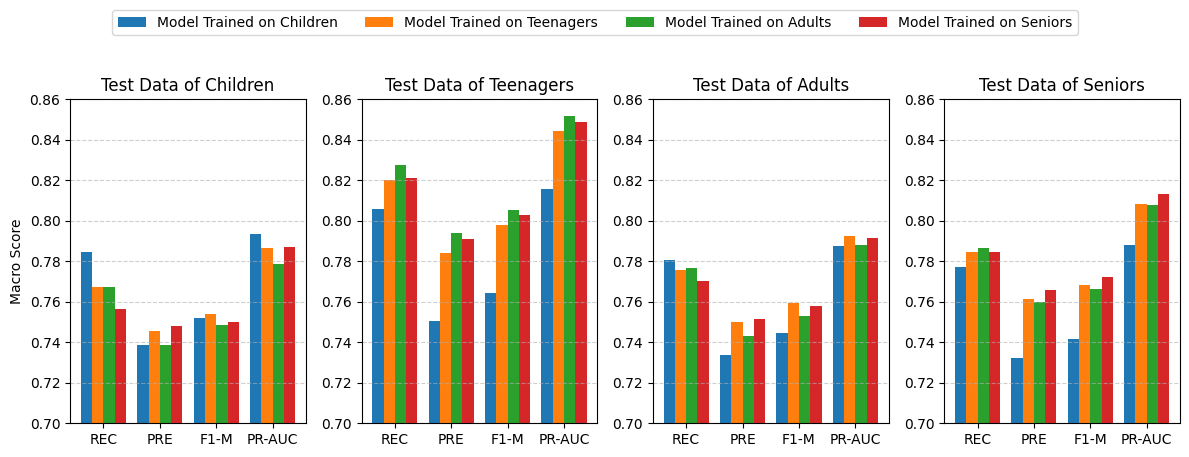

In [ ]:
groups = ["Test Data of Children", "Test Data of Teenagers", "Test Data of Adults", "Test Data of Seniors"]
models = ["Model Trained on Children", "Model Trained on Teenagers", "Model Trained on Adults", "Model Trained on Seniors"]
metrics = ["REC", "PRE", "F1-M", "PR-AUC"]

# results are extracted from previous prints 
data = {
"REC" : [
[0.7845, 0.7674, 0.7672, 0.7563],
[0.8059, 0.8201, 0.8277, 0.8211],
[0.7806, 0.7759, 0.7768, 0.7703], 
[0.7771, 0.7844, 0.7865, 0.7844]
],
"PRE" : [
[0.7389, 0.7456, 0.7387, 0.748 ],
[0.7505, 0.7843, 0.7942, 0.7909],
[0.7335, 0.7499, 0.7432, 0.7514],
[0.7324, 0.7615, 0.7597, 0.7656]
],
"F1-M" : [
[0.752,  0.754,  0.7486, 0.7498], 
[0.7643, 0.7978, 0.8055, 0.803 ],
[0.7446, 0.7593, 0.753,  0.7581],
[0.7414, 0.7685, 0.7664, 0.7721]
],
"PR-AUC": [
[0.7934, 0.7866, 0.7787, 0.7869],
[0.8159, 0.8446, 0.852,  0.8487],
[0.7874, 0.7927, 0.7881, 0.7916],
[0.7883, 0.8085, 0.8077, 0.8134]
],
}


fig, axes = plt.subplots(1, 4, figsize=(12, 4), sharey=False)
bar_width = 0.2
x = np.arange(len(metrics))

for i, group in enumerate(groups):
    ax = axes[i]
    for j, model in enumerate(models):
        values = [data[m][i][j] for m in metrics]   
        ax.bar(x + j*bar_width, values, width=bar_width, label=model)
    
    ax.set_xticks(x + bar_width * 1.5)
    ax.set_xticklabels(metrics)
    ax.set_ylim(0.7, 0.86)
    ax.set_title(group)
    ax.grid(axis= "y ", linestyle= "-- ", alpha=0.6)

axes[0].set_ylabel("Macro Score")
fig.legend(models, loc="lower center", ncol=4, bbox_to_anchor=(0.5, 1.05))
plt.tight_layout()
plt.show()